In [1]:
import pandas as pd
f=open('nndb_flat.csv')
food_data = pd.read_csv(f)
food_data.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [8]:
#1. Drop the useless colonums
food_data=food_data.drop(columns=['ID','ShortDescrip','Descrip','CommonName','MfgName','ScientificName'])
food_data = food_data[food_data.columns.drop(list(food_data.filter(regex='USRDA')))]
food_data.head()

,FoodGroup,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,Dairy and Egg Products,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,Dairy and Egg Products,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,Dairy and Egg Products,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


In [9]:
#2. the check of repeated data and duplicated datas
import numpy as np
#repeated rows
#food_data.isnull().any() 
print(food_data[food_data.isnull().values==True])

#process of duplicated rows
food_data.duplicated()
food_data.drop_duplicates()
food_data.shape

Empty DataFrame
Columns: [FoodGroup, Energy_kcal, Protein_g, Fat_g, Carb_g, Sugar_g, Fiber_g, VitA_mcg, VitB6_mg, VitB12_mcg, VitC_mg, VitE_mg, Folate_mcg, Niacin_mg, Riboflavin_mg, Thiamin_mg, Calcium_mg, Copper_mcg, Iron_mg, Magnesium_mg, Manganese_mg, Phosphorus_mg, Selenium_mcg, Zinc_mg]
Index: []

[0 rows x 24 columns]


(8618, 24)

In [10]:
#first, we will perform anomaly detection based entirely on domain knowledge

for feature in [x for x in food_data.columns if '_g' in x]:
    print(food_data[food_data[feature]>=100.0].shape)
#no instance with protein, fat, carb, sugar or fiber > 100. there are however instances with protein=100 and carb=100. let's look at those
food_data[(food_data.Fat_g>=100.0) | (food_data.Carb_g>=100.0)]
#fats and oils as well as artificial sweeteners. so the values make sense. there are nevertheless some traces of other nutrients found. however, we consider this to be in the range of measurement accuracy

(0, 24)
(97, 24)
(2, 24)
(0, 24)
(0, 24)


,FoodGroup,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
610,Fats and Oils,902.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.0,0.2,0.00
611,Fats and Oils,902.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.0,0.2,0.11
629,Fats and Oils,884.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.0,0.0,0.00
630,Fats and Oils,884.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.0,0.0,0.00
631,Fats and Oils,884.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.07,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8177,American Indian/Alaska Native Foods,900.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.0,0.0,0.00
8180,American Indian/Alaska Native Foods,900.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.0,0.0,0.00
8455,Fats and Oils,884.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.0,0.0,0.00
8509,Sweets,368.0,0.0,0.0,100.0,92.7,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.221,0.10,0.0,0.0,0.0,0.6,0.00


In [11]:
#now, let's sum over all features. however, let's excluse carb_g and fiber_g because they obviously depend on other features. 
s = 0.0
greater_100 = []
grams = [x for x in food_data.columns if ('_g' in x and 'Carb' not in x and 'Fiber' not in x)]
mgrams = [x for x in food_data.columns if '_mg' in x]
mcgrams = [x for x in food_data.columns if '_mcg' in x]

#using numpy to avoid float imprecisions
mg_1000 = np.float64(1000.0)
mcg_1000000 = np.float64(1000000.0)
for i in range(food_data.shape[0]):
    s = np.float64(0)
    for feature in grams:
        s += food_data.loc[i,feature]
        
    for feature in mgrams:
        s += food_data.loc[i,feature] / mg_1000
        
    for feature in mcgrams:
        s += food_data.loc[i,feature] / mcg_1000000
    #leaving some leverage room for potential imprecisions
    if(s > 100.1):
        greater_100.append(i)
        print(s)
food_data.iloc[greater_100,:]

#two instances found whose sum is slightly above 100.1. Again, fats and oils. So, we still consider these to be valid items.

100.1494
100.1703043


,FoodGroup,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
632,Fats and Oils,884.0,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8154,American Indian/Alaska Native Foods,899.0,0.56,99.6,0.0,0.0,0.0,10.0,0.0,0.0,...,0.0,0.011,0.0,0.0,0.0,0.0,0.0,0.0,3.3,0.0


In [12]:
df = food_data.drop(columns = ['FoodGroup'])
df

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,0.0,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,0.0,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,0.0,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,0.0,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,0.0,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,305.0,18.50,25.10,0.00,0.00,0.0,47.0,0.410,12.00,0.0,...,0.190,0.020,66.0,0.100,1.40,60.0,0.000,254.0,73.4,1.10
8614,111.0,20.54,0.84,5.41,0.00,0.0,2.0,0.112,2.15,0.0,...,0.024,0.012,10.0,0.033,0.58,37.0,0.029,426.0,21.7,1.55
8615,269.0,0.00,0.00,73.14,73.20,0.0,0.0,0.000,0.00,0.0,...,0.060,0.130,13.0,0.020,3.60,10.0,0.000,8.0,0.7,0.19
8616,90.0,16.10,1.40,2.00,0.00,0.0,30.0,0.130,0.50,0.0,...,0.120,0.010,10.0,0.400,3.50,250.0,0.000,272.0,27.4,1.00


In [20]:
from sklearn.neighbors import LocalOutlierFactor

dummy = pd.DataFrame()
for col in set(food_data.FoodGroup):
    X = food_data[food_data.FoodGroup==col]
    X = X.drop(columns=['FoodGroup'])
    clf = LocalOutlierFactor(n_neighbors=20, algorithm='auto', contamination=0.1, n_jobs=-1)
    clf.fit_predict(X)
    clf.kneighbors(X)
    vals = -clf._decision_function(X)
    bla = pd.DataFrame(vals, index=food_data[food_data.FoodGroup==col].index)
    dummy = dummy.append(bla)
    
food_data_lof = food_data.assign(lof=dummy)
food_data_lof

,FoodGroup,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg,lof
0,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,...,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09,0.578307
1,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,...,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05,0.579225
2,Dairy and Egg Products,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,...,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01,1.068213
3,Dairy and Egg Products,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,...,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66,-0.503732
4,Dairy and Egg Products,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,...,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60,-0.737995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,Finfish and Shellfish Products,305.0,18.50,25.10,0.00,0.00,0.0,47.0,0.410,12.00,...,0.020,66.0,0.100,1.40,60.0,0.000,254.0,73.4,1.10,-0.311300
8614,Finfish and Shellfish Products,111.0,20.54,0.84,5.41,0.00,0.0,2.0,0.112,2.15,...,0.012,10.0,0.033,0.58,37.0,0.029,426.0,21.7,1.55,0.017272
8615,Sweets,269.0,0.00,0.00,73.14,73.20,0.0,0.0,0.000,0.00,...,0.130,13.0,0.020,3.60,10.0,0.000,8.0,0.7,0.19,-0.709504
8616,Finfish and Shellfish Products,90.0,16.10,1.40,2.00,0.00,0.0,30.0,0.130,0.50,...,0.010,10.0,0.400,3.50,250.0,0.000,272.0,27.4,1.00,1.842976


In [21]:
items = []
for col in set(food_data_lof.FoodGroup):
    group = food_data_lof[food_data_lof.FoodGroup==col]
    std = group.lof.std()
    mean = group.lof.mean()
    for item in group.lof:
        items.append((item-mean)/std)

food_data_lof = food_data_lof.drop(columns=['lof'])
food_data_lof = food_data_lof.assign(lof=items)
food_data_lof.lof.mean()

-4.911171647281565e-17

In [22]:
for col in set(food_data_lof.FoodGroup):
    group = food_data_lof[food_data_lof.FoodGroup==col]
    std = group.lof.std()
    mean = group.lof.mean()
    to_be_dropped = group[(group.lof >= 0.9) | (group.lof <= -0.9)]
    print(f'{col} size before: {food_data_lof[food_data_lof.FoodGroup==col].shape[0]}    dropping: {len(to_be_dropped)}')
    food_data_lof = food_data_lof.drop(to_be_dropped.index)

Restaurant Foods size before: 108    dropping: 1
Breakfast Cereals size before: 363    dropping: 2
Lamb, Veal, and Game Products size before: 438    dropping: 37
Legumes and Legume Products size before: 389    dropping: 7
Beef Products size before: 946    dropping: 42
Beverages size before: 315    dropping: 16
Meals, Entrees, and Side Dishes size before: 113    dropping: 1
Sweets size before: 347    dropping: 28
Soups, Sauces, and Gravies size before: 452    dropping: 14
Pork Products size before: 343    dropping: 16
Nut and Seed Products size before: 133    dropping: 0
Fast Foods size before: 371    dropping: 21
Vegetables and Vegetable Products size before: 828    dropping: 57
Spices and Herbs size before: 64    dropping: 5
Baby Foods size before: 362    dropping: 7
Snacks size before: 171    dropping: 11
Cereal Grains and Pasta size before: 183    dropping: 21
Finfish and Shellfish Products size before: 267    dropping: 0
Dairy and Egg Products size before: 264    dropping: 23
Poult

In [23]:
food_data_lof.shape

(8178, 25)

In [24]:
#new dataset
f = "nndb_flat_lof.csv"
#food_data_lof.to_csv(f)

In [25]:
#lof results varied when run on different computers. we load the data here in order to provide replicable results
food_data = pd.read_csv('nndb_flat_lof.csv')
food_data.head()

,Unnamed: 0,FoodGroup,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,...,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg,lof
0,0,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,...,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09,0.092685
1,1,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,...,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05,-0.153993
2,2,Dairy and Egg Products,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,...,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01,-0.157274
3,3,Dairy and Egg Products,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,...,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66,-0.145267
4,4,Dairy and Egg Products,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,...,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60,-0.156169


In [26]:
food_data=food_data.drop(columns=['Unnamed: 0','lof'])

In [27]:
food_data

,FoodGroup,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,Dairy and Egg Products,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,Dairy and Egg Products,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,Dairy and Egg Products,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,Dairy and Egg Products,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8173,Finfish and Shellfish Products,305.0,18.50,25.10,0.00,0.00,0.0,47.0,0.410,12.00,...,0.190,0.020,66.0,0.100,1.40,60.0,0.000,254.0,73.4,1.10
8174,Finfish and Shellfish Products,111.0,20.54,0.84,5.41,0.00,0.0,2.0,0.112,2.15,...,0.024,0.012,10.0,0.033,0.58,37.0,0.029,426.0,21.7,1.55
8175,Sweets,269.0,0.00,0.00,73.14,73.20,0.0,0.0,0.000,0.00,...,0.060,0.130,13.0,0.020,3.60,10.0,0.000,8.0,0.7,0.19
8176,Finfish and Shellfish Products,90.0,16.10,1.40,2.00,0.00,0.0,30.0,0.130,0.50,...,0.120,0.010,10.0,0.400,3.50,250.0,0.000,272.0,27.4,1.00


/Users/bilegjargalbattulga/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

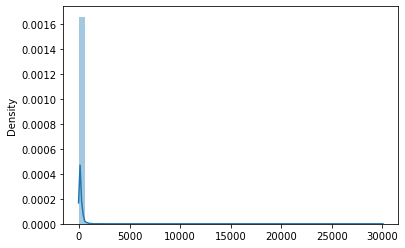

In [28]:
df = food_data.drop(columns = ['FoodGroup'])
sns.distplot(df)

In [29]:
#4. data normalization

food_data_exp = food_data.drop(columns=['FoodGroup'])
food_data_target = food_data.FoodGroup

from sklearn import preprocessing
food_data_exp = pd.DataFrame(
    preprocessing.MinMaxScaler().fit_transform(food_data_exp),
    columns=['Energy_kcal','Protein_g', 'Fat_g', 'Carb_g',
       'Sugar_g', 'Fiber_g', 'VitA_mcg', 'VitB6_mg', 'VitB12_mcg',
       'VitC_mg', 'VitE_mg', 'Folate_mcg', 'Niacin_mg', 'Riboflavin_mg',
       'Thiamin_mg', 'Calcium_mg', 'Copper_mcg', 'Iron_mg',
       'Magnesium_mg', 'Manganese_mg', 'Phosphorus_mg', 'Selenium_mcg',
       'Zinc_mg']
)
food_data_exp.head()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,0.794900,0.009624,0.8111,0.0006,0.000601,0.0,0.022800,0.000250,0.001719,0.0,...,0.001943,0.000214,0.005540,0.000000,0.000162,0.002561,0.000000,0.003494,0.000522,0.000990
1,0.794900,0.009624,0.8111,0.0006,0.000601,0.0,0.022800,0.000250,0.001315,0.0,...,0.001943,0.000214,0.005540,0.001063,0.001294,0.002561,0.000012,0.003348,0.000522,0.000550
2,0.971175,0.003170,0.9948,0.0000,0.000000,0.0,0.028000,0.000083,0.000101,0.0,...,0.000286,0.000043,0.000923,0.000066,0.000000,0.000000,0.000000,0.000437,0.000000,0.000110
3,0.391353,0.242301,0.2874,0.0234,0.005010,0.0,0.006600,0.013833,0.012337,0.0,...,0.021829,0.001241,0.121884,0.002658,0.002508,0.029449,0.000027,0.056340,0.007564,0.029247
4,0.411308,0.263134,0.2968,0.0279,0.005110,0.0,0.009733,0.005417,0.012741,0.0,...,0.020057,0.000599,0.155586,0.001595,0.003479,0.030730,0.000037,0.065657,0.007564,0.028587


In [15]:
#5. Feature selection according to the correlation
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import pandas as pd
pd.set_option('display.max_colwidth', -1)
pd.options.display.max_columns = 27
from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity(food_data_exp.iloc[:,0:].transpose())
similarities = pd.DataFrame(similarities, columns=food_data_exp.columns[0:], index=food_data_exp.columns[0:])
similarities

<ipython-input-15-28978b4a5962>:5: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option('display.max_colwidth', -1)


,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,VitE_mg,Folate_mcg,Niacin_mg,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
Energy_kcal,1.000000,0.633667,0.849344,0.723890,0.514850,0.444475,0.114950,0.449060,0.215808,0.087609,0.355812,0.287575,0.544722,0.453717,0.398596,0.385803,0.311823,0.447371,0.532141,0.084908,0.636663,0.349990,0.459805
Protein_g,0.633667,1.000000,0.439886,0.301298,0.158528,0.267816,0.104374,0.489240,0.367282,0.055134,0.141700,0.193191,0.629932,0.463299,0.333349,0.321588,0.335313,0.385484,0.495921,0.085277,0.756445,0.523954,0.611805
Fat_g,0.849344,0.439886,1.000000,0.309798,0.237585,0.214106,0.089759,0.232468,0.136991,0.025449,0.399340,0.095294,0.302234,0.229691,0.200149,0.228190,0.211551,0.205638,0.329600,0.043005,0.420771,0.250839,0.299095
Carb_g,0.723890,0.301298,0.309798,1.000000,0.705978,0.588489,0.080867,0.439056,0.104197,0.144249,0.189625,0.405672,0.474099,0.455133,0.436369,0.391409,0.248292,0.522209,0.507055,0.091997,0.464062,0.168791,0.307205
Sugar_g,0.514850,0.158528,0.237585,0.705978,1.000000,0.277170,0.064980,0.279604,0.077580,0.114590,0.149870,0.251256,0.275656,0.303632,0.242777,0.286461,0.133010,0.283730,0.248467,0.043915,0.249930,0.074555,0.201107
Fiber_g,0.444475,0.267816,0.214106,0.588489,0.277170,1.000000,0.060091,0.400208,0.073839,0.130695,0.234848,0.324608,0.346828,0.327400,0.329183,0.388942,0.308138,0.506442,0.638502,0.124949,0.411295,0.141708,0.280464
VitA_mcg,0.114950,0.104374,0.089759,0.080867,0.064980,0.060091,1.000000,0.179172,0.551557,0.133914,0.072817,0.135406,0.193504,0.331630,0.096917,0.088250,0.514709,0.148577,0.084902,0.400590,0.126909,0.090805,0.112235
VitB6_mg,0.449060,0.489240,0.232468,0.439056,0.279604,0.400208,0.179172,1.000000,0.358119,0.300247,0.337471,0.582070,0.783134,0.673398,0.512619,0.335545,0.248638,0.590467,0.457876,0.097245,0.484895,0.279476,0.574361
VitB12_mcg,0.215808,0.367282,0.136991,0.104197,0.077580,0.073839,0.551557,0.358119,1.000000,0.042564,0.116171,0.215890,0.376684,0.485538,0.194360,0.115055,0.558516,0.274872,0.140917,0.270868,0.308949,0.301306,0.387946
VitC_mg,0.087609,0.055134,0.025449,0.144249,0.114590,0.130695,0.133914,0.300247,0.042564,1.000000,0.088876,0.098877,0.247042,0.262685,0.100743,0.166521,0.069355,0.124424,0.164318,0.028353,0.100202,0.022864,0.082463


In [16]:
food_data_exp.corr()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,VitE_mg,Folate_mcg,Niacin_mg,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
Energy_kcal,1.000000,0.113075,0.810032,0.480454,0.309132,0.196089,0.028998,0.120040,-0.011519,-0.034207,0.305811,0.141852,0.173559,0.154671,0.184114,0.148047,0.109043,0.197628,0.253930,0.037101,0.237934,0.057343,0.111197
Protein_g,0.113075,1.000000,0.054437,-0.296643,-0.264515,-0.070076,0.021516,0.225822,0.249643,-0.066024,-0.031358,0.006607,0.373454,0.202333,0.097013,0.067324,0.164022,0.118426,0.217711,0.040836,0.530065,0.371473,0.412753
Fat_g,0.810032,0.054437,1.000000,-0.056866,-0.005833,-0.027884,0.026382,-0.049827,-0.022493,-0.060452,0.341167,-0.059215,-0.025974,-0.039332,-0.007518,0.021942,0.047853,-0.041231,0.071006,-0.000766,0.083566,0.038201,0.026614
Carb_g,0.480454,-0.296643,-0.056866,1.000000,0.617633,0.458705,0.006041,0.201565,-0.092368,0.077416,0.068188,0.325015,0.180896,0.238894,0.283086,0.213814,0.072177,0.363276,0.288108,0.055297,0.086996,-0.110976,-0.009538
Sugar_g,0.309132,-0.264515,-0.005833,0.617633,1.000000,0.114439,0.013232,0.088212,-0.050334,0.062534,0.061310,0.160402,0.034759,0.127273,0.097777,0.145591,-0.003302,0.121174,0.039454,0.010921,-0.056850,-0.119580,-0.022806
Fiber_g,0.196089,-0.070076,-0.027884,0.458705,0.114439,1.000000,0.009382,0.247103,-0.050372,0.081917,0.160121,0.246715,0.140053,0.163199,0.205182,0.272461,0.204587,0.398290,0.544178,0.101604,0.193317,-0.032126,0.086569
VitA_mcg,0.028998,0.021516,0.026382,0.006041,0.013232,0.009382,1.000000,0.138238,0.542905,0.119372,0.047343,0.108445,0.151750,0.312731,0.056042,0.045554,0.505419,0.107529,0.027599,0.395174,0.061753,0.046243,0.059143
VitB6_mg,0.120040,0.225822,-0.049827,0.201565,0.088212,0.247103,0.138238,1.000000,0.265888,0.270805,0.270281,0.541268,0.705492,0.578992,0.410394,0.187758,0.117541,0.485856,0.285059,0.068001,0.251267,0.108312,0.437833
VitB12_mcg,-0.011519,0.249643,-0.022493,-0.092368,-0.050334,-0.050372,0.542905,0.265888,1.000000,0.005161,0.058371,0.155546,0.275586,0.418739,0.102293,0.010437,0.516809,0.179947,0.001800,0.260083,0.172916,0.216055,0.298563
VitC_mg,-0.034207,-0.066024,-0.060452,0.077416,0.062534,0.081917,0.119372,0.270805,0.005161,1.000000,0.061078,0.067004,0.208848,0.227796,0.055077,0.125651,0.028818,0.074624,0.112664,0.017967,0.014266,-0.034133,0.016846


In [17]:
#Drop the Energy_kcal
X=food_data_exp.drop(columns=['Energy_kcal'])
X

,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,VitE_mg,Folate_mcg,Niacin_mg,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,0.009624,0.8111,0.0006,0.000601,0.0,0.022800,0.000250,0.001719,0.0,0.015529,0.000510,0.000329,0.001943,0.000214,0.005540,0.000000,0.000162,0.002561,0.000000,0.003494,0.000522,0.000990
1,0.009624,0.8111,0.0006,0.000601,0.0,0.022800,0.000250,0.001315,0.0,0.015529,0.000510,0.000329,0.001943,0.000214,0.005540,0.001063,0.001294,0.002561,0.000012,0.003348,0.000522,0.000550
2,0.003170,0.9948,0.0000,0.000000,0.0,0.028000,0.000083,0.000101,0.0,0.018742,0.000000,0.000024,0.000286,0.000043,0.000923,0.000066,0.000000,0.000000,0.000000,0.000437,0.000000,0.000110
3,0.242301,0.2874,0.0234,0.005010,0.0,0.006600,0.013833,0.012337,0.0,0.001673,0.006121,0.007969,0.021829,0.001241,0.121884,0.002658,0.002508,0.029449,0.000027,0.056340,0.007564,0.029247
4,0.263134,0.2968,0.0279,0.005110,0.0,0.009733,0.005417,0.012741,0.0,0.001740,0.003401,0.000925,0.020057,0.000599,0.155586,0.001595,0.003479,0.030730,0.000037,0.065657,0.007564,0.028587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8173,0.209466,0.2510,0.0000,0.000000,0.0,0.001567,0.034167,0.121347,0.0,0.015930,0.002551,0.025882,0.010857,0.000856,0.015235,0.006645,0.011327,0.076825,0.000000,0.036978,0.038289,0.012095
8174,0.232563,0.0084,0.0541,0.000000,0.0,0.000067,0.009333,0.021741,0.0,0.000000,0.003401,0.008439,0.001371,0.000513,0.002308,0.002193,0.004693,0.047375,0.000088,0.062018,0.011320,0.017042
8175,0.000000,0.0000,0.7314,0.733467,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000784,0.003429,0.005561,0.003001,0.001329,0.029126,0.012804,0.000000,0.001165,0.000365,0.002089
8176,0.182292,0.0140,0.0200,0.000000,0.0,0.001000,0.010833,0.005056,0.0,0.033467,0.001020,0.010980,0.006857,0.000428,0.002308,0.026578,0.028317,0.320102,0.000000,0.039598,0.014293,0.010995


In [18]:
#6. PCA and LDA for Dimensionality reduction 
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import StandardScaler
# 1. PCA
pca = PCA(n_components=0.95)# ensure to keep 95% of the information of dataset after dimensiona reduction
pca.fit(X)
X_PCA=pca.transform(X)
print(X_PCA[:])
X_PCA.shape

[[-0.24119569  0.67799128 -0.19622227 ...  0.03757411 -0.00227135
   0.00339145]
 [-0.24111747  0.67800279 -0.19606962 ...  0.03774329 -0.00219693
   0.00337136]
 [-0.2490355   0.85978977 -0.21582281 ...  0.04602481 -0.0025539
   0.00820173]
 ...
 [ 0.71008478 -0.06983089 -0.2225746  ... -0.04309256  0.01028418
   0.00275507]
 [-0.19088559 -0.08110443  0.11613298 ... -0.13640969  0.03034918
  -0.10331369]
 [-0.23537052 -0.10734434  0.05031379 ... -0.02461725  0.00099321
  -0.00634902]]


(8178, 8)

In [19]:
# LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
X_LDA=LDA(n_components=8).fit_transform(X, food_data_target)#Parameter n_components is the dimensionality after dimension reduction
X_LDA

array([[-3.69431520e-01,  2.38764764e-01,  5.93256336e+00, ...,
        -2.81361872e-01,  4.79995895e-01, -2.09348892e-01],
       [-3.60494664e-01,  2.50970326e-01,  5.92923037e+00, ...,
        -2.81168290e-01,  4.69525098e-01, -2.21969265e-01],
       [-4.63888507e-01, -1.98291285e-01,  7.39714874e+00, ...,
        -3.57843696e-01,  4.75873453e-01, -4.22909265e-01],
       ...,
       [ 3.15957742e+00,  1.23532759e-01, -9.22658936e-01, ...,
         2.06619067e+00, -4.11459282e+00, -1.09976202e+00],
       [-4.10906056e-01,  2.42426085e+00, -5.23277238e-03, ...,
        -4.76615426e-01, -2.30388276e+00,  1.15477717e+00],
       [-1.62144783e+00,  8.31325227e-01, -6.81068141e-01, ...,
         5.97527217e-01,  4.46301082e-01,  8.87808330e-02]])

In [20]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
#The dataset here is the one after PCA:X_PCA; Dataset without dimension reduction: X; Dataset with LDA:X_LDA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_PCA, food_data_target, test_size=0.3, random_state=0)
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_LDA, food_data_target, test_size=0.3, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, food_data_target, test_size=0.3, random_state=0)

print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
sm = SMOTE(random_state=2)
X_train_pca_res, y_train_pca_res = sm.fit_sample(X_train_pca, y_train_pca.ravel())
y_train_pca_res = pd.Series(y_train_pca_res)
X_train_pca_res = pd.DataFrame(X_train_pca_res)
X_train_pca_res.shape

X_train_lda_res, y_train_lda_res = sm.fit_sample(X_train_lda, y_train_lda.ravel())
y_train_lda_res = pd.Series(y_train_lda_res)
X_train_lda_res = pd.DataFrame(X_train_lda_res)
X_train_lda_res.shape

X_train_res, y_train_res = sm.fit_sample(X_train, y_train.ravel())
y_train_res = pd.Series(y_train_res)
X_train_res = pd.DataFrame(X_train_res)
X_train_res.shape



In [ ]:
for cat in set(y_train_res):
    print(f"Before --> After OverSampling: ({cat}) {sum(y_train==cat)} --> {sum(y_train_res==cat)}")
print('\n')
for cat in set(y_train_lda_res):
    print(f"Before --> After OverSampling: ({cat}) {sum(y_train==cat)} --> {sum(y_train_lda_res==cat)}")
print('\n')
for cat in set(y_train_pca_res):
    print(f"Before --> After OverSampling: ({cat}) {sum(y_train_pca==cat)} --> {sum(y_train_pca_res==cat)}")

In [ ]:
#auxiliary method to draw a confusion matrix with a high number of features. we just use the pandas dataframe here since it facilitates formating 

from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def create_confusion_matrix(y_true, y_pred):
    labels_short = [x[:5] for x in unique_labels(y_true, y_pred)]
    cm = pd.DataFrame(confusion_matrix(y_test, y_pred), columns=labels_short, index=labels_short)
    s1 = [sum(cm.loc[l,:]) for l in labels_short]
    s2 = [sum(cm.loc[:,l]) for l in labels_short]
    s2.append(sum(s1))
    cm = cm.assign(pred_sum=s1)
    cm = cm.transpose()
    cm = cm.assign(actual_sum=s2)
    cm = cm.transpose()
    return cm

In [ ]:
#testing sci-kit learns dummy classifiers. As the class sizes have been balanced, a majority classifier will obviously show a very low accuracy

from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

types = ["stratified", "most_frequent", "prior", "uniform"]
dummies = {}
for t in types:
    d = DummyClassifier(t)
    d.fit(X_train_res, y_train_res)
    dummies[t] = accuracy_score(y_test, d.predict(X_test))
m = max(dummies, key=dummies.get)
print(f"best dummy classifier is {m}, accuracy: {dummies[m]}")

In [ ]:
#testing sci-kit learns dummy classifiers. As the class sizes have been balanced, a majority classifier will obviously show a very low accuracy

from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

types = ["stratified", "most_frequent", "prior", "uniform"]
dummies = {}
for t in types:
    d = DummyClassifier(t)
    d.fit(X_train_pca_res, y_train_pca_res)
    dummies[t] = accuracy_score(y_test_pca, d.predict(X_test_pca))
m = max(dummies, key=dummies.get)
print(f"best dummy classifier is {m}, accuracy: {dummies[m]}")

In [ ]:
#testing sci-kit learns dummy classifiers. As the class sizes have been balanced, a majority classifier will obviously show a very low accuracy

from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

types = ["stratified", "most_frequent", "prior", "uniform"]
dummies = {}
for t in types:
    d = DummyClassifier(t)
    d.fit(X_train_pca_res, y_train_lda_res)
    dummies[t] = accuracy_score(y_test_lda, d.predict(X_test_lda))
m = max(dummies, key=dummies.get)
print(f"best dummy classifier is {m}, accuracy: {dummies[m]}")

In [ ]:
#we use a decision tree with a maximum depth of 4 instead.
from sklearn import tree
decision_tree = tree.DecisionTreeClassifier(max_depth=4, criterion='gini')
decision_tree.fit(X_train_res, y_train_res)
pred = decision_tree.predict(X_test)
print(classification_report(y_test, pred))
print(accuracy_score(y_test, pred))

In [ ]:
#we use a decision tree with a maximum depth of 4 instead.
from sklearn import tree
decision_tree = tree.DecisionTreeClassifier(max_depth=4, criterion='gini')
decision_tree.fit(X_train_pca_res, y_train_pca_res)
pred = decision_tree.predict(X_test_pca)
print(classification_report(y_test, pred))
print(accuracy_score(y_test, pred))

In [ ]:
#we use a decision tree with a maximum depth of 4 instead.
from sklearn import tree
decision_tree = tree.DecisionTreeClassifier(max_depth=4, criterion='gini')
decision_tree.fit(X_train_lda_res, y_train_lda_res)
pred = decision_tree.predict(X_test_lda)
print(classification_report(y_test, pred))
print(accuracy_score(y_test, pred))

In [ ]:
seed = 2
from sklearn.neighbors import KNeighborsClassifier
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from collections import defaultdict


results_knn = defaultdict(list)
#storing information for the various knn classifiers in a dictionary
for w in ['distance', 'uniform']:
    for n_neighbors in range(2, 10):
        knn_estimator = KNeighborsClassifier(n_neighbors, weights=w)
        knn_estimator.fit(X_train_res, y_train_res)
        pred = knn_estimator.predict(X_test)
        results_knn[(w, n_neighbors)].append(accuracy_score(y_test, pred))
        results_knn[(w, n_neighbors)].append(f1_score(y_test, pred, average='weighted'))
        results_knn[(w, n_neighbors)].append(classification_report(y_test, pred))
        results_knn[(w, n_neighbors)].append(create_confusion_matrix(y_test, pred))

print(f'max f1:{max(results_knn, key=lambda x: results_knn[x][1])}\n')
for k, v in results_knn.items():
    print(f"knn with {k}:     f1 = {v[1]}")

In [ ]:
print(results_knn[('distance', 3)][2])

In [ ]:
results_knn = defaultdict(list)
#storing information for the various knn classifiers in a dictionary
for w in ['distance', 'uniform']:
    for n_neighbors in range(2, 10):
        knn_estimator = KNeighborsClassifier(n_neighbors, weights=w)
        knn_estimator.fit(X_train_pca_res, y_train_pca_res)
        pred = knn_estimator.predict(X_test_pca)
        results_knn[(w, n_neighbors)].append(accuracy_score(y_test, pred))
        results_knn[(w, n_neighbors)].append(f1_score(y_test, pred, average='weighted'))
        results_knn[(w, n_neighbors)].append(classification_report(y_test, pred))
        results_knn[(w, n_neighbors)].append(create_confusion_matrix(y_test, pred))

print(f'max f1:{max(results_knn, key=lambda x: results_knn[x][1])}\n')
for k, v in results_knn.items():
    print(f"knn with {k}:     f1 = {v[1]}")

In [ ]:
print(results_knn[('distance', 3)][2])

In [ ]:
results_knn = defaultdict(list)
#storing information for the various knn classifiers in a dictionary
for w in ['distance', 'uniform']:
    for n_neighbors in range(2, 10):
        knn_estimator = KNeighborsClassifier(n_neighbors, weights=w)
        knn_estimator.fit(X_train_lda_res, y_train_lda_res)
        pred = knn_estimator.predict(X_test_lda)
        results_knn[(w, n_neighbors)].append(accuracy_score(y_test, pred))
        results_knn[(w, n_neighbors)].append(f1_score(y_test, pred, average='weighted'))
        results_knn[(w, n_neighbors)].append(classification_report(y_test, pred))
        results_knn[(w, n_neighbors)].append(create_confusion_matrix(y_test, pred))

print(f'max f1:{max(results_knn, key=lambda x: results_knn[x][1])}\n')
for k, v in results_knn.items():
    print(f"knn with {k}:     f1 = {v[1]}")

In [ ]:
print(results_knn[('distance', 5)][2])

In [ ]:
from sklearn.neighbors.nearest_centroid import NearestCentroid
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold

nearest_centroid = NearestCentroid()
nearest_centroid.fit(X_train_res, y_train_res)
pred = nearest_centroid.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

In [ ]:
nearest_centroid = NearestCentroid()
nearest_centroid.fit(X_train_pca_res, y_train_pca_res)
pred = nearest_centroid.predict(X_test_pca)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

In [ ]:
nearest_centroid = NearestCentroid()
nearest_centroid.fit(X_train_lda_res, y_train_lda_res)
pred = nearest_centroid.predict(X_test_lda)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

In [ ]:
from sklearn import tree
results_dc = defaultdict(list)
for c in ['gini', 'entropy']:
    for depth in range(5, 40):
        decision_tree = tree.DecisionTreeClassifier(max_depth=depth, criterion=c)
        decision_tree.fit(X_train_res, y_train_res)
        prediction = decision_tree.predict(X_test)

        results_dc[(c, depth)].append(accuracy_score(y_test, prediction))
        results_dc[(c, depth)].append(f1_score(y_test, prediction, average='weighted'))
        results_dc[(c, depth)].append(classification_report(y_test, prediction))
        results_dc[(c, depth)].append(create_confusion_matrix(y_test, prediction))
        
print(f'max f1:{max(results_dc, key=lambda x: results_dc[x][1])}\n')
for k, v in results_dc.items():
    print(f"dc with max_depth={k}:    acc={v[0]}    f1 = {v[1]} ")

In [ ]:
print(results_dc[('entropy', 23)][2])

In [ ]:
results_dc = defaultdict(list)
for c in ['gini', 'entropy']:
    for depth in range(5, 40):
        decision_tree = tree.DecisionTreeClassifier(max_depth=depth, criterion=c)
        decision_tree.fit(X_train_pca_res, y_train_pca_res)
        prediction = decision_tree.predict(X_test_pca)

        results_dc[(c, depth)].append(accuracy_score(y_test, prediction))
        results_dc[(c, depth)].append(f1_score(y_test, prediction, average='weighted'))
        results_dc[(c, depth)].append(classification_report(y_test, prediction))
        results_dc[(c, depth)].append(create_confusion_matrix(y_test, prediction))
print(f'max f1:{max(results_dc, key=lambda x: results_dc[x][1])}\n')

for k, v in results_dc.items():
    print(f"dc with max_depth={k}:    acc={v[0]}    f1 = {v[1]} ")        
     

In [ ]:
print(results_dc[('entropy', 25)][2])

In [ ]:
results_dc = defaultdict(list)
for c in ['gini', 'entropy']:
    for depth in range(5, 40):
        decision_tree = tree.DecisionTreeClassifier(max_depth=depth, criterion=c)
        decision_tree.fit(X_train_lda_res, y_train_lda_res)
        prediction = decision_tree.predict(X_test_lda)

        results_dc[(c, depth)].append(accuracy_score(y_test, prediction))
        results_dc[(c, depth)].append(f1_score(y_test, prediction, average='weighted'))
        results_dc[(c, depth)].append(classification_report(y_test, prediction))
        results_dc[(c, depth)].append(create_confusion_matrix(y_test, prediction))
print(f'max f1:{max(results_dc, key=lambda x: results_dc[x][1])}\n')

for k, v in results_dc.items():
    print(f"dc with max_depth={k}:    acc={v[0]}    f1 = {v[1]} ")      
     

In [ ]:
print(results_dc[('entropy', 26)][2])

In [ ]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

naive_bayes.fit(X_train_res, y_train_res)
pred = naive_bayes.predict(X_test)
print(f"naive bayes accuracy: {accuracy_score(y_test, pred)}")
print(classification_report(y_test, pred))

#again, American/Indian foods with considerably low scores

In [ ]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train_pca_res, y_train_pca_res)
pred = naive_bayes.predict(X_test_pca)
print(f"naive bayes accuracy: {accuracy_score(y_test, pred)}")
print(classification_report(y_test, pred))

In [ ]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train_lda_res, y_train_lda_res)
pred = naive_bayes.predict(X_test_lda)
print(f"naive bayes accuracy: {accuracy_score(y_test, pred)}")
print(classification_report(y_test, pred))

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from keras.utils import np_utils
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

np.random.seed(seed)
encoder = LabelEncoder()
encoder.fit(y_train.ravel())

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from keras.utils import np_utils
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

np.random.seed(seed)


In [ ]:
num_nodes = 0
def model1():
    print(num_nodes)
    model = Sequential()
    #22 input nodes, 24 hidden nodes
    model.add(Dense(num_nodes, input_dim=22, activation='relu'))
    model.add(Dense(num_nodes, input_dim=num_nodes, activation='relu'))
    #25 output nodes
    model.add(Dense(25, activation='softmax'))
    # Compile model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

num_nodes = 0
def model2():
    print(num_nodes)
    model = Sequential()
    #22 input nodes, 24 hidden nodes
    model.add(Dense(num_nodes, input_dim=8, activation='relu'))
    model.add(Dense(num_nodes, input_dim=num_nodes, activation='relu'))
    #25 output nodes
    model.add(Dense(25, activation='softmax'))
    # Compile model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

num_nodes = 0
def model3():
    print(num_nodes)
    model = Sequential()
    #22 input nodes, 24 hidden nodes
    model.add(Dense(num_nodes, input_dim=8, activation='relu'))
    model.add(Dense(num_nodes, input_dim=num_nodes, activation='relu'))
    #25 output nodes
    model.add(Dense(25, activation='softmax'))
    # Compile model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
results_nn_res = defaultdict(list)
for i in range(10):
    num_nodes += 16
    estimator = KerasClassifier(model1, epochs=50, batch_size=5, verbose=1)
    estimator.fit(X_train_res, y_train_res) #for model2
    pred = estimator.predict(X_test)
    results_nn_res[num_nodes].append(accuracy_score(y_test, pred))
    #results_nn_res[num_nodes].append(f1_score(y_test, pred))
    results_nn_res[num_nodes].append(classification_report(y_test, pred))
    results_nn_res[num_nodes].append(create_confusion_matrix(y_test, pred))
#print(f'max f1:{min(results_nn_res, key=lambda x: results_nn_res[x][1])}\n')
#for k, v in results_nn_res.items():
#    print(f"nn with {k} nodes in the hidden layer:    acc={v[0]}")

In [ ]:
results_nn_pca = defaultdict(list)
num_nodes = 0
for i in range(10):
    num_nodes += 16
    estimator = KerasClassifier(model2, epochs=50, batch_size=5, verbose=1)
    estimator.fit(X_train_pca_res, y_train_pca_res) #for model2
    pred = estimator.predict(X_test_pca)
    results_nn_pca[num_nodes].append(accuracy_score(y_test, pred))
    #results_nn_pca[num_nodes].append(f1_score(y_test, pred))
    results_nn_pca[num_nodes].append(classification_report(y_test, pred))
    results_nn_pca[num_nodes].append(create_confusion_matrix(y_test, pred))
#print(f'max f1:{min(results_nn_pca, key=lambda x: results_nn_pca[x][1])}\n')
#for k, v in results_nn_pca.items():
#    print(f"nn with {k} nodes in the hidden layer:    acc={v[0]}")

In [ ]:
results_nn_lda = defaultdict(list)
num_nodes = 0
for i in range(10):
    num_nodes += 16
    estimator = KerasClassifier(model3, epochs=50, batch_size=5, verbose=1)
    estimator.fit(X_train_lda_res, y_train_lda_res) #for model2
    pred = estimator.predict(X_test_lda)
    results_nn_lda[num_nodes].append(accuracy_score(y_test, pred))
    #results_nn_lda[num_nodes].append(f1_score(y_test, pred))
    results_nn_lda[num_nodes].append(classification_report(y_test, pred))
    results_nn_lda[num_nodes].append(create_confusion_matrix(y_test, pred))
#print(f'max f1:{min(results_nn_lda, key=lambda x: results_nn_lda[x][1])}\n')
#for k, v in results_nn_lda.items():
#    print(f"nn with {k} nodes in the hidden layer:    acc={v[0]}")

In [ ]:
#print(f'max f1:{min(results_nn_res, key=lambda x: results_nn_res[x][1])}\n')
for k, v in results_nn_res.items():
    print(f"nn with {k} nodes in the hidden layer:    acc={v[0]}")
    print(f"nn with {k} nodes in the hidden layer:    acc={v[1]}")
    



In [ ]:
#n=144 found to be working best by comparing f1 scores
print(results_nn_res[144][1])

In [ ]:
for k, v in results_nn_pca.items():
    print(f"nn with {k} nodes in the hidden layer:    acc={v[0]}")
    print(f"nn with {k} nodes in the hidden layer:    acc={v[1]}")

In [ ]:
#n=144 found to be working best by comparing f1 scores
print(results_nn_pca[144][1])

In [ ]:
for k, v in results_nn_lda.items():
    print(f"nn with {k} nodes in the hidden layer:    acc={v[0]}")
    print(f"nn with {k} nodes in the hidden layer:    acc={v[1]}")

In [ ]:
#n=144 found to be working best by comparing f1 scores
print(results_nn_lda[144][1])